## A node-based Formulation for the CVRP 

##### Keywords:  CVRP, Subtours, Linear Programming, Cplex, Python, Networkx, Docplex, node-based

$ \text{Variables} $

$x_{ij}={\begin{cases}1&{\text{the path goes from city }}i{\text{ to city }}j\\0&{\text{otherwise}}\end{cases}}$

$u_{i}=\text{indicate the load of a vehicle
right after departing from customer i.}$

\begin{equation*}
\begin{aligned}
& \underset{}{\text{Minimize}}
& & \sum_{i=1}^{n} \sum_{j=1, j\neq i}^{n} c_{ij} x_{ij} \\
& \text{Subject to}
& & \sum_{j=1, j\neq i}^{n} x_{ji} = 1, \quad i = 2,\ldots,n, \\
& 
& & \sum_{j=1, i\neq j}^{n} x_{ij} = 1, \quad i = 2,\ldots,n, \\
& 
& & u_{i} - u_{j} + Q x_{ij} +(Q-q_{i}-q_{j})*x_{ij} \leq Q - q_{j}, \quad i,j = 2, \ldots,n, \, i\neq j, .\\
&
& & u_{i} \ge q_{i} + \sum_{j=2, j\neq i}^{n} q_{j}x_{ji} , \quad i = 2, \ldots,n, \,\\
&
& & u_{i} \leq Q - \sum_{j=2, j\neq i}^{n} q_{j}x_{ij} , \quad i =2, \ldots,n, \,\\
&
& & u_{i} \leq Q - (Q-q_{i})X_{1i} , \quad i = 2, \ldots,n, \,\\
&
& & u_{i} \leq Q - (Q-\underset{\text{$j = 2,\ldots,n, \, i\neq j$}}{\text{max{$q_{j}$}}}{}-q_{i})X_{1i}-\sum_{j=2, j\neq i}^{n} q_{j}x_{ij} , \quad i = 1, \ldots,n, \,\\
&
& & x_{ij} \in \{0,1\}, \quad i,j = 1,\ldots,n, \, i\neq j, \\
&
& & u_{i} \ge 0, \quad i=2,\ldots ,n.
\end{aligned}
\end{equation*}


#### Import Library and Model Enviroment

In [1]:
from docplex.mp.model import Model
import networkx as nx   
import numpy as np
import matplotlib.pyplot as plt
import math
mdl=Model('A node-based CVRP')

#### Function to Import the Data

In [2]:
def import_txt(filename):
    """
    This function imports data from a Vehicle Routing Problem (VRP) instance from a text file.

    Parameters:
    file (str): The name of the file (without the .vrp extension) that contains the VRP instance data.

    Returns:
    coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
    coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
    Name (str): The name of the VRP instance.
    Nodes (int): The number of nodes in the VRP instance.
    Capacity (int): The capacity of the vehicles in the VRP instance.
    Trucks (int): The number of trucks available in the VRP instance.
    Demand (list): A list of the demands at each node in the VRP instance.
    N (list): A list of the node numbers in the VRP instance.
    Arc (list): A list of tuples representing all possible arcs between nodes in the VRP instance.

    Usage Example:
    coord_x, coord_y, Name, Nodes, Capacity, Trucks, D, N, Arc = import_txt('my_vrp_instance')
    """
    file = open(filename+'.vrp') 
    Data = file.readlines()
    file.close()
    Name= str(Data[0].split()[2])
    Nodes= int(Data[3].split()[2])
    Capacity= int(Data[5].split()[2])
    Trucks = int((Data[1].split()[8]).replace(",",""))
    coord_x=[int(Data[i].split()[1]) for i in range(7,7+Nodes)]
    coord_y=[int(Data[i].split()[2]) for i in range(7,7+Nodes)]
    Demand=[int(Data[i].split()[1]) for i in range(7+Nodes+1,7+Nodes+1+Nodes)]
    N=[i+1 for i in range(Nodes)]
    Arc =[(i,j) for i in N for j in N if i!=j]
    
    
    return coord_x,coord_y,Name,Nodes,Capacity,Trucks,Demand,N,Arc

In [3]:
coord_x,coord_y,Name,Nodes,Capacity,Trucks,Demand,N,Arc=import_txt("P-n16-k8")

#### Create dictonary of Distances

In [4]:
def distance(coord_x, coord_y, arcos):
    """
    This function calculates the Euclidean distance (Int) between each pair of nodes in a Vehicle Routing Problem (VRP) instance.

    Parameters:
    coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
    coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
    arcos (list): A list of tuples representing all possible arcs between nodes in the VRP instance.

    Returns:
    distancia (dict): A dictionary where the keys are the arcs (pairs of nodes) and the values are the Euclidean distances between the nodes.

    """

    distance = {(i, j): round(math.sqrt((coord_x[i-1] - coord_x[j-1])**2 + (coord_y[i-1] - coord_y[j-1])**2),2) for i,j in arcos}
    
    return distance


#### Parameters

In [5]:
C=distance(coord_x,coord_y, Arc)
k=Trucks
Q=Capacity
q=Demand

#### Sets

In [6]:
N=[i+1 for i in range(Nodes)]

#### Index

In [7]:
Ind1={(i,j) for i in N for j in N}
Ind2={(i) for i in N}

#### Variables

In [8]:
x=mdl.binary_var_dict(Ind1, name='x')
u=mdl.continuous_var_dict(Ind2, name='u')

#### Mathematical Model of A Node-Based Formulation for the Capacited Vehicle Routing Problem (A Node-Based CVRP)

#### Objective Function

In [9]:
mdl.minimize(mdl.sum(C[i,j]*x[i,j] for i in N for j in N if i!=j))

#### Subject to:

In [10]:
for i in N:
    if i!=1:
        mdl.add_constraint(mdl.sum(x[i,j] for j in N if i!=j)==1)

In [11]:
for i in N:
    if i!=1:
        mdl.add_constraint(mdl.sum(x[j,i] for j in N if i!=j)==1)

In [12]:
for i in N:
    for j in N:
        if i!=1:
            if j!=1:
                if i!=j:
                    mdl.add_constraint(u[i]-u[j]+Q*x[i,j]+(Q-q[i-1]-q[j-1])*x[j,i]<=Q-q[j-1])

In [13]:
for i in N:
    if i!=1:
        mdl.add_constraint(u[i]>=q[i-1]+mdl.sum(q[j-1]*x[j,i] for j in N if i!=1 if i!=j))

In [14]:
for i in N:
    if i!=1:
        mdl.add_constraint(u[i]<=Q-mdl.sum(q[j-1]*x[i,j] for j in N if i!=j if i!=1))

In [15]:
for i in N:
    if i!=1:
        mdl.add_constraint(u[i]<=Q-(Q-q[i-1])*x[1,i])

In [16]:
for i in N:
    if i!=1:
        mdl.add_constraint(u[i]<=Q-(Q-max(q)-q[i-1])*x[1,i]-mdl.sum(q[j-1]*x[i,j] for j in N if i!=j if i!=1))

In [17]:
for i in N:
    mdl.add_constraint(u[i]>=0)

#### Solve A node-based formulation for the CVRP

Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
Tried aggregator 1 time.
MIP Presolve eliminated 127 rows and 109 columns.
MIP Presolve modified 2 coefficients.
Reduced MIP has 189 rows, 163 columns, and 1064 nonzeros.
Reduced MIP has 150 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.01 sec. (0.83 ticks)
Found incumbent of value 759.820000 after 0.01 sec. (1.69 ticks)
Probing time = 0.00 sec. (0.84 ticks)
Cover probing fixed 0 vars, tightened 1 bounds.
Tried aggregator 1 time.
Detecting symmetries...
MIP Presolve modified 9 coefficients.
Reduced MIP has 189 rows, 163 columns, and 1064 nonzeros.
Reduced MIP has 150 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.81 ticks)
Probing time = 0.00 sec. (0.79 ticks)
Clique table members: 638.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Par

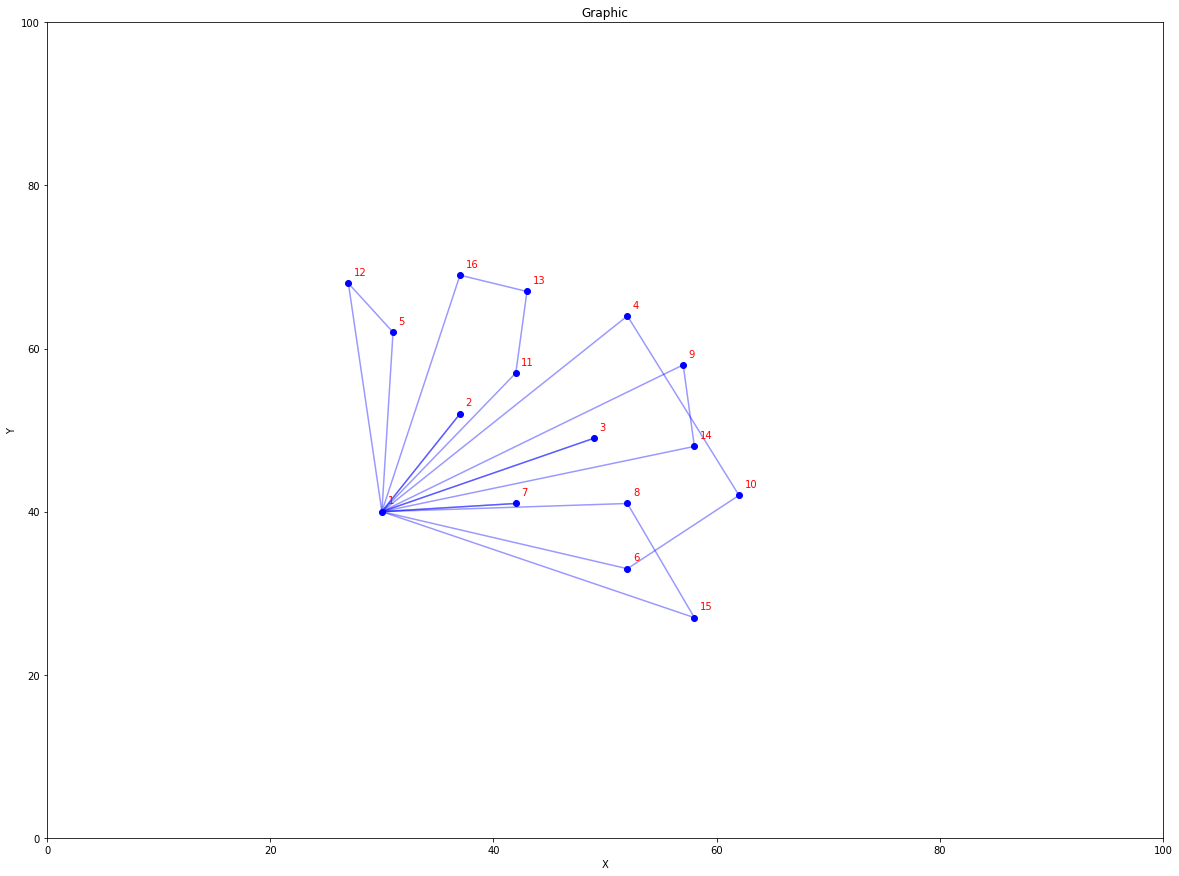

In [18]:
"""
This script uses the CPLEX optimization library to solve a Vehicle Routing Problem (VRP) instance. 

First, it sets a time limit for the optimization process using the `mdl.parameters.timelimit` attribute. Then, it solves the problem and displays the solution using the `mdl.solve` and `solucion.display` methods, respectively.

The solution is then extracted into two dictionaries, `sx` and `su`, using the `solucion.get_value_dict` method. These dictionaries contain the solution values for the decision variables `x` and `u`, respectively.

Finally, the script plots the solution on a graph. The nodes are represented as points, and the arcs that are included in the solution are represented as lines between the points. The plot includes labels for the nodes and axes, and a title.

Parameters:
mdl (Model): The CPLEX model object representing the VRP instance.
x (dict): A dictionary where the keys are the arcs (pairs of nodes) and the values are the decision variables representing whether or not each arc is included in the solution.
u (dict): A dictionary where the keys are the nodes and the values are the decision variables representing the load of each vehicle at each node.
coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
Arc (list): A list of tuples representing all possible arcs between nodes in the VRP instance.
N (list): A list of the node numbers in the VRP instance.

Usage Example:
# Assuming `mdl`, `x`, `coord_x`, `coord_y`, `Arc`, and `N` are already defined...
mdl.parameters.timelimit = 300
solucion = mdl.solve(log_output=True)
solucion.display()
sx = solucion.get_value_dict(x, keep_zeros=True, precision=1)
su = solucion.get_value_dict(u, keep_zeros=True, precision=1)
# Plotting code here...
"""

#661
#mdl.parameters.timelimit=500
solucion=mdl.solve(log_output=True)
solucion.display()
sx=solucion.get_value_dict(x, keep_zeros=True, precision=1)

plt.figure(figsize=(20,15))#size of the figure
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Graphic")#title

actives_arcs = [i for i in Arc if x[i].solution_value > 0.9]

for i,j in actives_arcs:
    plt.plot([coord_x[i-1],coord_x[j-1]],[coord_y[i-1],coord_y[j-1]],color='b', alpha=0.4, zorder=0)
    
plt.scatter(x=coord_x, y=coord_y, color='blue', zorder=1)
  
for n in N:
    plt.annotate(str(n), xy=(coord_x[n-1],coord_y[n-1] ), xytext=(coord_x[n-1]+0.5,coord_y[n-1]+1),color='red')

plt.xlim((0,100))
plt.ylim((0,100))
plt.show()

$ Literature $

Aksen, D., Oncan, T., & Sadati, M.E. (2018). An Empirical Investigation of Four Well-Known Polynomial-Size VRP Formulations. arXiv: Optimization and Control. pp. 1-5.

Capacitated Vehicle Routing Problem Library http://vrp.galgos.inf.puc-rio.br/index.php/en/

